In [74]:
import datajoint as dj

connection = dj.conn()

In [28]:
subject = dj.create_virtual_module('subject', 'u19_subject')
scheduler = dj.create_virtual_module('scheduler', 'u19_scheduler')
lab = dj.create_virtual_module('lab', 'u19_lab')
acquisition = dj.create_virtual_module('acquisition', 'u19_acquisition')

rec = dj.create_virtual_module("u19_recording", "u19_recording")
ephys_pipeline = dj.create_virtual_module("u19_ephys_pipeline", "u19_ephys_pipeline")

subject_fullname = 'jyanar_ya008'
session_date = '2024-05-25'

In [29]:
key = {
    'subject_fullname': subject_fullname,
    'session_date': session_date
    }


In [30]:
rec_id = (rec.Recording().BehaviorSession() & key).fetch1('recording_id')
key['recording_id'] = rec_id

In [31]:
temp = (ephys_pipeline.BehaviorSync() & key)
display(temp)
trial_index_nidq = (temp).fetch1('trial_index_nidq')
iteration_index_nidq = (temp).fetch1('iteration_index_nidq')
nidq_sampling_rate = (temp).fetch1('nidq_sampling_rate')

recording_id Unique number assigned to recording,nidq_sampling_rate sampling rate of behavioral iterations niSampRate in nidq meta file,iteration_index_nidq Virmen index time series. Length of this longblob should be the number of samples in the nidaq file.,trial_index_nidq Trial index time series. length of this longblob should be the number of samples in the nidaq file.
315,5000.06,=BLOB=,=BLOB=


20517.0


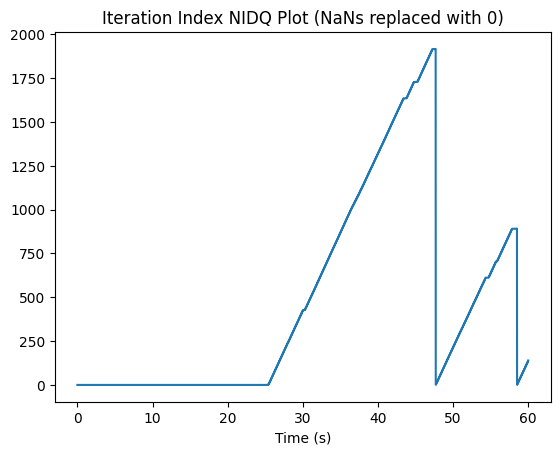

[1.000e+00 2.000e+00 1.917e+03]
The 10 most frequent non-zero values are:
Value: 1916.0, Count: 1903
Value: 1635.0, Count: 1850
Value: 1729.0, Count: 1528
Value: 427.0, Count: 1207
Value: 1728.0, Count: 874
Value: 1917.0, Count: 223
Value: 1634.0, Count: 178
Value: 3.0, Count: 148
Value: 4.0, Count: 145
Value: 2.0, Count: 123


In [73]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

iteration_index_nidq_nan_to_zero = np.nan_to_num(iteration_index_nidq, nan=0)
print(max(iteration_index_nidq_nan_to_zero))
# iteration_index_nidq_nan_to_zero = iteration_index_nidq
iteration_index_nidq_nan_to_zero = iteration_index_nidq_nan_to_zero[:300000]
# plt.plot(iteration_index_nidq_nan_to_zero)
# plt.xlabel("Index")
# plt.ylabel("Iteration Index NIDQ")
plt.title("Iteration Index NIDQ Plot (NaNs replaced with 0)")
time = np.arange(iteration_index_nidq_nan_to_zero.size) / nidq_sampling_rate
plt.plot(time, iteration_index_nidq_nan_to_zero)
plt.xlabel("Time (s)")
plt.title("Iteration Index NIDQ Plot (NaNs replaced with 0)")
# plt.xlim(47.6, 48)
plt.show()

time_slice = iteration_index_nidq_nan_to_zero[int(47.65 * nidq_sampling_rate):int(47.69 * nidq_sampling_rate)]
unique_values = np.unique(time_slice)
print(unique_values)

time_slice_47_70 = iteration_index_nidq_nan_to_zero[:int(47.67 * nidq_sampling_rate)]

non_zero_values = time_slice_47_70[time_slice_47_70 > 0]
counts = Counter(non_zero_values)
most_common_values = counts.most_common(10)

print("The 10 most frequent non-zero values are:")
for value, count in most_common_values:
    print(f"Value: {value}, Count: {count}")

# count = np.sum(iteration_index_nidq_nan_to_zero[:int(47.70 * nidq_sampling_rate)] == max_val)
# print(f"The maximum value is: {max_val}")
# print(f"The number of instances of the maximum value before time 47.70 is: {count}")

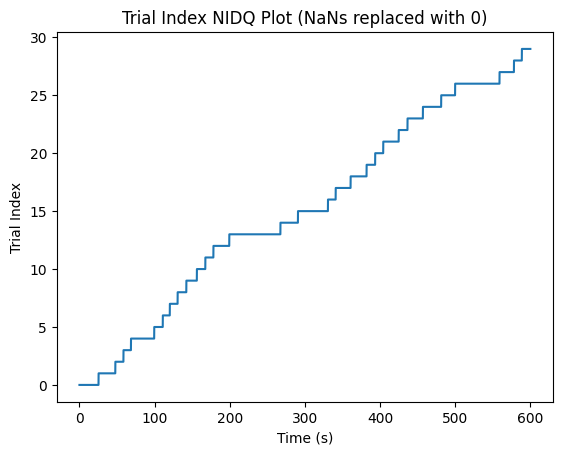

In [67]:
trial_index_nidq_nan_to_zero = np.nan_to_num(trial_index_nidq, nan=0)
trial_index_nidq_nan_to_zero = trial_index_nidq_nan_to_zero[:int(600 * nidq_sampling_rate)]
plt.figure()
plt.title("Trial Index NIDQ Plot (NaNs replaced with 0)")
time = np.arange(trial_index_nidq_nan_to_zero.size) / nidq_sampling_rate
plt.plot(time, trial_index_nidq_nan_to_zero)
plt.xlabel("Time (s)")
plt.ylabel("Trial Index")
plt.show()

In [ ]:
trial_index_nidq_nan_to_zero = np.nan_to_num(trial_index_nidq, nan=0)

integer_values = []
start_indices = []
end_indices = []

max_trials = np.max(trial_index_nidq_nan_to_zero)

max_it = min(3, max_trials)

for integer in range(1,max_it+1):
    indices = np.where(trial_index_nidq_nan_to_zero == integer)[0]
    if len(indices) > 0:
        start_indices.append(indices[0])
        end_indices.append(indices[-1])
    else:
        start_indices.append(None)
        end_indices.append(None)

buffer_time = 1.5  # seconds
buffer_samples = int(buffer_time * nidq_sampling_rate)

for i, integer in enumerate(range(1,max_it+1)):
    print(f"Trial: {integer}, Starting Nidq Index: {start_indices[i]}, End Index: {end_indices[i]}")

Trial: 1, Starting Nidq Index: 126753, Ending Nidq Index: 238356
Trial: 2, Starting Nidq Index: 238357, Ending Nidq Index: 292460
Trial: 3, Starting Nidq Index: 292461, Ending Nidq Index: 342419


In [76]:
trial_index_nidq_nan_to_zero = np.nan_to_num(trial_index_nidq, nan=0)

start_indices = []

max_trials = np.max(trial_index_nidq_nan_to_zero)

for integer in range(1, int(max_trials)+1):
    indices = np.where(trial_index_nidq_nan_to_zero == integer)[0]
    if len(indices) > 0:
        start_indices.append(indices[0])
    else:
        start_indices.append(None)

trial_start_times = []
for start_index in start_indices:
    if start_index is not None:
        trial_start_times.append(start_index / nidq_sampling_rate)
    else:
        trial_start_times.append(None)

# for i, integer in enumerate(range(1, int(max_trials)+1)):
#     print(f"Trial: {integer}, Starting Nidq Index: {start_indices[i]}, Start Time: {trial_start_times[i]} seconds")

subject_fullname username_mouse_nickname,session_date date of experiment,session_number number,session_start_time start time,session_location,task,local_path_behavior_file Path were session file is stored in local computer,remote_path_behavior_file Path were session file will be stored in bucket,new_remote_path_behavior_file Unified Path were session file will be stored in cup,is_finished Flag that indicates if this session was finished successfully,invalid_session Flag that indicates if behavioral file couldn't be saved for the session %}
jyanar_ya008,2024-05-25,0,2024-05-25 12:29:00,185A-Rig1,Towers,C:\Data\jyanar\data\jyanar_ya008\jorge_pwmv2_cohort1_185A-Rig1_jyanar_ya008_T_20240525_0.mat,/braininit/RigData/training/npx/behav/jyanar/data/jyanar_ya008/jorge_pwmv2_cohort1_185A-Rig1_jyanar_ya008_T_20240525_0.mat,braininit/Data/Raw/behavior/jyanar/jyanar_ya008/20240525_g0/jorge_pwmv2_cohort1_185A-Rig1_jyanar_ya008_T_20240525_0.mat,1,0


In [87]:
from tank_lab_to_nwb import VirmenDataInterface

file_path = '/Users/ct5868/test_data_for_nwb/yanar/jessejorge_pwm_jessejorge_pwm_pilot_165I-miniVR-T-5_jyanar_ya009_T_20240310.mat'
vm_interface = VirmenDataInterface(file_path)

# You can now access the data through the vm_interface object
# For example, to get the trial data:
trial_data = vm_interface.get_original_timestamps()

# Print the keys of the trial data to understand its structure
print(vm_interface.get_metadata())
print(vm_interface.get_metadata_schema())

DeepDict: {'NWBFile': {'session_description': '', 'identifier': '8636dd02-2e66-4f50-a049-7b056492928b', 'source_script': 'Created using NeuroConv v0.7.1', 'source_script_file_name': '/Users/ct5868/code/tank-lab-to-nwb/.venv/lib/python3.13/site-packages/neuroconv/basedatainterface.py', 'experimenter': ['FAKE PERSON'], 'session_start_time': datetime.datetime(2024, 3, 10, 15, 25, 43, 101000)}, 'Subject': {'subject_id': {'name': 'jyanar_ya009', 'Profile': 8, 'Date': array([2024,    3,    8], dtype=uint16), 'Time': 20, 'waterAlloc': 1, 'rewardFactor': array([[2. , 1.5, 1.2, 1. , 1. , 1.2, 1.2, 1.2, 1.2, 1.2, 1.4, 1.5, 1.6,
        1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
        1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
        1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
        1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
        1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8, 1.8,
        1